# Local Feature Size Estimation

Exploring how estimates of local feature size vary with noise

More formally, define the medial axis of $K$ by

$$
\operatorname{Med}(K):=\left\{u \in \mathbb{R}^D \mid \exists x_1 \neq x_2 \in K \quad\left\|u-x_1\right\|=\left\|u-x_2\right\|=\mathrm{d}(u, K)\right\} .
$$


The reach of $K$ is then defined as the smallest distance between $K$ and $\operatorname{Med}(K)$. Definition 3.1. For all closed $K \subset \mathbb{R}^D$, the reach of $K$ is defined by

$$
\operatorname{rch}(K):=\min _{x \in K} \mathrm{~d}(x, \operatorname{Med}(K))=\inf _{u \in \operatorname{Med}(K)} \mathrm{d}(u, K) .
$$

Let $K$ be a compact subset of $\mathbb{R}^D, \mathrm{~d}$ a distance on $K$ and $\delta>0$. The spherical distortion radius of the metric space ( $K, \mathrm{~d}$ ) at scale $\delta$ is defined by

$$
\operatorname{sdr}_\delta(K, \mathrm{~d}):=\sup \left\{r>0 \mid \forall x, y \in K, \delta \leqslant\|x-y\|<2 r \Rightarrow \mathrm{~d}(x, y) \leqslant \mathrm{d}_{\mathcal{S}(r)}(x, y)\right\} .
$$


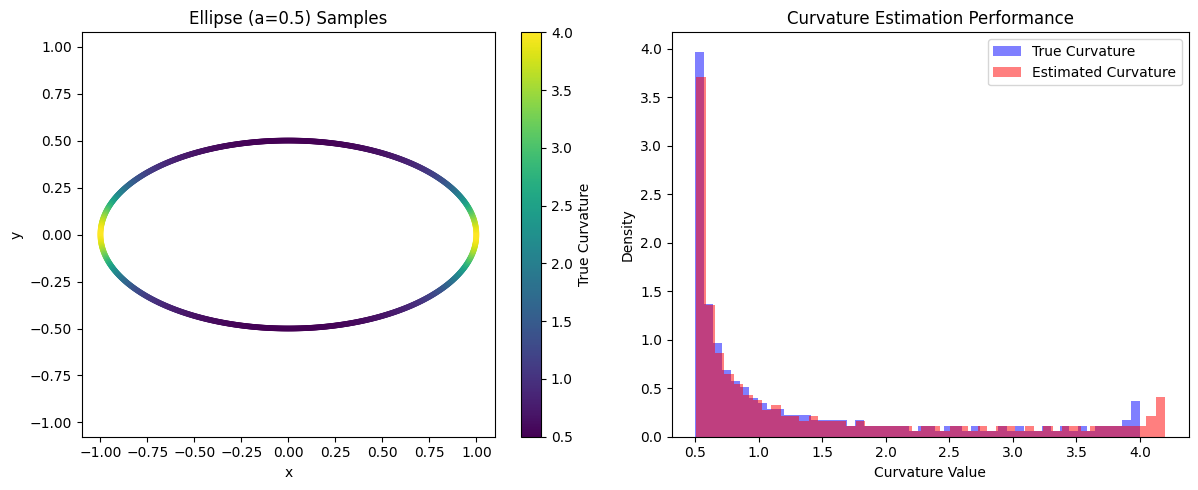

Mean Absolute Error in Curvature Estimation: 0.1052


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# 1. Parameter setup
a = 0.5
n_points = 1000
h = 0.25 # Bandwidth for local polynomial fitting

# 2. Sample points uniformly according to arc length
def ellipse_arc_length_element(theta, a):
    # x = cos(theta), y = a*sin(theta)
    # dx/dtheta = -sin(theta), dy/dtheta = a*cos(theta)
    return np.sqrt(np.sin(theta)**2 + (a**2) * (np.cos(theta)**2))

# Compute cumulative arc length
thetas = np.linspace(0, 2 * np.pi, 2000)
arc_lengths = [quad(ellipse_arc_length_element, 0, t, args=(a,))[0] for t in thetas]
total_length = arc_lengths[-1]

# Interpolate to find thetas that give uniform spacing in arc length
s_to_theta = interp1d(arc_lengths, thetas)
s_uniform = np.linspace(0, total_length, n_points, endpoint=False)
theta_uniform = s_to_theta(s_uniform)

# Coordinates of sampled points
X = np.vstack([np.cos(theta_uniform), a * np.sin(theta_uniform)]).T

# 3. True Curvature calculation
# Formula: k = a / (sin^2(t) + a^2*cos^2(t))^1.5
true_curvatures = a / (np.sin(theta_uniform)**2 + (a**2) * np.cos(theta_uniform)**2)**1.5

# 4. Local Curvature Estimation (Local Polynomial Regression)
est_curvatures = []

for i in range(n_points):
    p_i = X[i]
    # Find neighbors within distance h
    diff = X - p_i
    dist = np.linalg.norm(diff, axis=1)
    neighbors = diff[dist < h]
    
    if len(neighbors) < 3:
        est_curvatures.append(0)
        continue
    
    # Stage 1: Local PCA to find tangent space (d=1)
    pca = PCA(n_components=2)
    pca.fit(neighbors)
    # The first component is the tangent direction, second is normal
    tangent_vec = pca.components_[0]
    normal_vec = pca.components_[1]
    
    # Transform neighbors to local coordinate system (tangent, normal)
    # Note: neighbors are already centered at p_i
    y = neighbors @ tangent_vec # local x-axis (tangent)
    z = neighbors @ normal_vec  # local y-axis (normal)
    
    # Stage 2: Fit second-order polynomial z = b2*y^2 + b1*y + b0
    # The paper's k-th order estimator for k=3 corresponds to degree 2
    Y_poly = np.column_stack([y**2, y, np.ones_like(y)])
    reg = LinearRegression().fit(Y_poly, z)
    
    # Curvature k = |f''(0)| / (1 + f'(0)^2)^1.5. 
    # Since we aligned the axis with the tangent, f'(0) is approx 0.
    # The coefficient b2 of y^2 is 0.5 * f''(0).
    k_est = 2 * np.abs(reg.coef_[0])
    est_curvatures.append(k_est)

est_curvatures = np.array(est_curvatures)

# 5. Plotting Results
plt.figure(figsize=(12, 5))

# Plot the Ellipse and Tangent Spaces (Visualization)
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], c=true_curvatures, cmap='viridis', s=10, label='Data points')
plt.colorbar(label='True Curvature')
plt.axis('equal')
plt.title(f"Ellipse (a={a}) Samples")
plt.xlabel("x")
plt.ylabel("y")

# Histogram Comparison
plt.subplot(1, 2, 2)
plt.hist(true_curvatures, bins=50, alpha=0.5, label='True Curvature', color='blue', density=True)
plt.hist(est_curvatures, bins=50, alpha=0.5, label='Estimated Curvature', color='red', density=True)
plt.title("Curvature Estimation Performance")
plt.xlabel("Curvature Value")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

# Mean Absolute Error
mae = np.mean(np.abs(true_curvatures - est_curvatures))
print(f"Mean Absolute Error in Curvature Estimation: {mae:.4f}")

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import wasserstein_distance
from ipywidgets import interact, FloatSlider, FloatLogSlider, Layout

# 1. Utility function for generating Ellipse data
def get_ellipse_data(a, n_points):
    def arc_length_element(theta, a):
        return np.sqrt(np.sin(theta)**2 + (a**2) * (np.cos(theta)**2))

    # Reference points for arc length parameterization
    thetas_ref = np.linspace(0, 2 * np.pi, 2000)
    arc_lengths = [quad(arc_length_element, 0, t, args=(a,))[0] for t in thetas_ref]
    total_length = arc_lengths[-1]
    
    # Interpolate to get uniform arc-length points
    s_to_theta = interp1d(arc_lengths, thetas_ref)
    s_uniform = np.linspace(0, total_length, n_points, endpoint=False)
    theta_uniform = s_to_theta(s_uniform)
    
    # Coordinates and True Curvature
    X_clean = np.vstack([np.cos(theta_uniform), a * np.sin(theta_uniform)]).T
    # Analytical curvature of ellipse: k = a / (sin^2(t) + a^2*cos^2(t))^1.5
    true_k = a / (np.sin(theta_uniform)**2 + (a**2) * np.cos(theta_uniform)**2)**1.5
    return X_clean, true_k

# 2. Main interactive update function
def update_plot(n_points, sigma, h, a):
    n_int = int(n_points)
    X_clean, true_curvatures = get_ellipse_data(a, n_int)
    
    # Add Gaussian Noise
    X_noisy = X_clean + np.random.normal(0, sigma, X_clean.shape)
    
    est_curvatures = []
    for i in range(len(X_noisy)):
        p_i = X_noisy[i]
        diff = X_noisy - p_i
        dist = np.linalg.norm(diff, axis=1)
        neighbors = diff[dist < h]
        
        # Polynomial fit stability check
        if len(neighbors) < 6:
            est_curvatures.append(0)
            continue
            
        pca = PCA(n_components=2)
        pca.fit(neighbors)
        tangent, normal = pca.components_[0], pca.components_[1]
        
        y, z = neighbors @ tangent, neighbors @ normal
        Y_poly = np.column_stack([y**2, y, np.ones_like(y)])
        
        try:
            reg = LinearRegression().fit(Y_poly, z)
            # The second fundamental form estimator from the paper: kappa = 2 * |beta_2|
            est_curvatures.append(2 * np.abs(reg.coef_[0]))
        except:
            est_curvatures.append(0)
            
    est_curvatures = np.array(est_curvatures)
    
    # Calculate Earth Mover's Distance
    emd = wasserstein_distance(true_curvatures, est_curvatures)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left Plot: Geometry
    ax1.scatter(X_noisy[:,0], X_noisy[:,1], alpha=0.3, s=max(1, 2000/n_int), label='Noisy Data')
    ax1.plot(X_clean[:,0], X_clean[:,1], 'r--', alpha=0.6, label='True Ellipse')
    # Use raw string r"" to fix SyntaxWarning for \sigma
    ax1.set_title(fr"Ellipse: n={n_int}, $\sigma$={sigma}, a={a}")
    ax1.set_xlim(-1.2, 1.2)
    ax1.set_ylim(-1.2, 1.2)
    ax1.set_aspect('equal')
    ax1.legend()

    # Right Plot: Distributions
    ax2.hist(true_curvatures, bins=40, alpha=0.4, label='True (Clean)', color='blue', density=True)
    ax2.hist(est_curvatures, bins=40, alpha=0.4, label='Est (Noisy)', color='red', density=True)
    
    # Set x-limit dynamically based on the ellipse curvature range
    ax2.set_xlim(0, max(true_curvatures.max() * 1.5, 5))
    ax2.set_title(f"Curvature Dist. (EMD: {emd:.4f})")
    ax2.set_xlabel("Curvature")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# 3. Setup UI
slider_style = {'description_width': 'initial'}
slider_layout = Layout(width='500px')

interact(
    update_plot, 
    n_points = FloatLogSlider(
        value=1000, base=10, min=1, max=4, step=0.01, 
        description=r'Number of Points ($n$)', 
        style=slider_style, layout=slider_layout
    ),
    sigma = FloatSlider(
        min=0, max=0.05, step=0.002, value=0.01, 
        description=r'Noise Std Dev ($\sigma$)',
        readout_format='.2e', 
        style=slider_style, layout=slider_layout
    ),
    h = FloatSlider(
        min=0.05, max=0.6, step=0.01, value=0.25, 
        description='Bandwidth ($h$)', 
        readout_format='.2e',
        style=slider_style, layout=slider_layout
    ),
    a = FloatSlider(
        min=0.01, max=1.0, step=0.01, value=0.5, 
        description='Semi-minor axis ($a$)', 
        style=slider_style, layout=slider_layout
    )
);

interactive(children=(FloatLogSlider(value=1000.0, description='Number of Points ($n$)', layout=Layout(width='…

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import wasserstein_distance
from ipywidgets import interact, FloatSlider, FloatLogSlider, Layout

# 1. Utility: Generate Ellipse and Analytical Geometry
def get_ellipse_data(a, n_points):
    def arc_length_element(theta, a):
        return np.sqrt(np.sin(theta)**2 + (a**2) * (np.cos(theta)**2))

    thetas_ref = np.linspace(0, 2 * np.pi, 5000)
    arc_lengths = [quad(arc_length_element, 0, t, args=(a,))[0] for t in thetas_ref]
    total_length = arc_lengths[-1]
    
    s_to_theta = interp1d(arc_lengths, thetas_ref)
    s_uniform = np.linspace(0, total_length, n_points, endpoint=False)
    theta_uniform = s_to_theta(s_uniform)
    
    X_clean = np.vstack([np.cos(theta_uniform), a * np.sin(theta_uniform)]).T
    true_k = a / (np.sin(theta_uniform)**2 + (a**2) * np.cos(theta_uniform)**2)**1.5
    return X_clean, true_k, total_length

def get_exact_basis(p_noisy, a):
    def dist_sq(theta):
        px, py = np.cos(theta), a * np.sin(theta)
        return (px - p_noisy[0])**2 + (py - p_noisy[1])**2
    
    res = minimize_scalar(dist_sq, bounds=(0, 2*np.pi), method='bounded')
    theta_proj = res.x
    nx, ny = np.cos(theta_proj), (1/a) * np.sin(theta_proj)
    normal = np.array([nx, ny])
    normal /= np.linalg.norm(normal)
    tangent = np.array([-normal[1], normal[0]])
    return tangent, normal

def get_theoretical_pdf(a, L, k_range):
    """Calculates the PDF of curvature for an ellipse sampled by arc length."""
    # Clip range slightly to avoid division by zero at boundaries
    k_min, k_max = a, 1/(a**2)
    # k_vals between k_min and k_max
    k = k_range[(k_range > k_min) & (k_range < k_max)]
    
    u = (a / k)**(2/3)
    numerator = 4 * a
    denominator = 3 * L * (k**2) * np.sqrt((u - a**2) * (1 - u))
    pdf = numerator / denominator
    
    # Return matched indices
    return k, pdf

# 2. Main interactive update function
def update_plot(n_points, sigma, h, a):
    n_int = int(n_points)
    X_clean, true_curvatures, L = get_ellipse_data(a, n_int)
    X_noisy = X_clean + np.random.normal(0, sigma, X_clean.shape)
    
    k_min, k_max = a, 1/(a**2)
    est_pca, est_exact = [], []
    
    for i in range(len(X_noisy)):
        p_i = X_noisy[i]
        diff = X_noisy - p_i
        dist = np.linalg.norm(diff, axis=1)
        neighbors = diff[dist < h]
        
        if len(neighbors) < 6:
            est_pca.append(0); est_exact.append(0)
            continue
            
        pca = PCA(n_components=2); pca.fit(neighbors)
        t_pca, n_pca = pca.components_[0], pca.components_[1]
        t_ex, n_ex = get_exact_basis(p_i, a)
        
        def get_k(tangent, normal, pts):
            y, z = pts @ tangent, pts @ normal
            Y_poly = np.column_stack([y**2, y, np.ones_like(y)])
            reg = LinearRegression().fit(Y_poly, z)
            return 2 * np.abs(reg.coef_[0])

        try:
            est_pca.append(get_k(t_pca, n_pca, neighbors))
            est_exact.append(get_k(t_ex, n_ex, neighbors))
        except:
            est_pca.append(0); est_exact.append(0)
            
    est_pca, est_exact = np.array(est_pca), np.array(est_exact)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left Plot
    ax1.scatter(X_noisy[:,0], X_noisy[:,1], alpha=0.3, s=max(1, 2000/n_int), label='Noisy Data')
    ax1.plot(X_clean[:,0], X_clean[:,1], 'k--', alpha=0.6, label='True Ellipse')
    ax1.set_title(fr"Ellipse Geometry: $\sigma$={sigma:.1e}, a={a}")
    ax1.set_xlim(-1.2, 1.2); ax1.set_ylim(-1.2, 1.2); ax1.set_aspect('equal')

    # Right Plot (Distribution)
    x_limit = max(k_max * 1.3, 5)
    bins = np.linspace(0, x_limit, 60)
    
    # Histograms
    ax2.hist(true_curvatures, bins=bins, alpha=0.15, label='Sample Truth', color='grey', density=True)
    ax2.hist(est_pca, bins=bins, alpha=0.35, label='Empirical (PCA)', color='red', density=True)
    ax2.hist(est_exact, bins=bins, alpha=0.35, label='Exact Tangent', color='blue', density=True)
    
    # Theoretical Continuous PDF Line
    k_grid = np.linspace(k_min + 1e-5, k_max - 1e-5, 500)
    k_pdf_x, k_pdf_y = get_theoretical_pdf(a, L, k_grid)
    ax2.plot(k_pdf_x[5:-5], k_pdf_y[5:-5], color='#00000080', linewidth=2.5, label='Theoretical PDF', zorder=10)
    
    # Reference Bounds
    ax2.axvline(k_min, color='blue', linestyle='--', alpha=0.5, label=fr'Min $\kappa={k_min:.2f}$')
    ax2.axvline(k_max, color='blue', linestyle=':', alpha=0.5, label=fr'Max $\kappa={k_max:.2f}$')
    
    ax2.set_title(fr"Curvature Distributions (n={n_int})")
    ax2.set_xlabel("Curvature Value")
    ax2.set_xlim(0, x_limit)
    ax2.set_ylim(0, max(k_pdf_y[10:-10]) * 1.5) # Avoid infinite spikes in limit
    ax2.legend(loc='upper right', fontsize='x-small', ncol=2)
    
    plt.tight_layout()
    plt.show()

# 3. Setup UI
slider_style = {'description_width': 'initial'}
slider_layout = Layout(width='500px')

interact(
    update_plot, 
    n_points = FloatLogSlider(value=1000, base=10, min=1, max=4, step=0.1, 
                              description='Number of Points ($n$)', 
                              readout_format='.2d', style=slider_style, layout=slider_layout),
    sigma = FloatSlider(min=0, max=0.05, step=0.0001, value=0.002, 
                        description=r'Noise Std Dev ($\sigma$)', 
                        readout_format='.2e', style=slider_style, layout=slider_layout),
    h = FloatSlider(min=0.05, max=0.6, step=0.01, value=0.25, 
                    description='Bandwidth ($h$)', style=slider_style, layout=slider_layout),
    a = FloatSlider(min=0.1, max=1.0, step=0.05, value=0.5, 
                    description='Semi-minor axis ($a$)', style=slider_style, layout=slider_layout)
);

interactive(children=(FloatLogSlider(value=1000.0, description='Number of Points ($n$)', layout=Layout(width='…

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import wasserstein_distance
from ipywidgets import interact, FloatSlider, FloatLogSlider, Layout

# 1. Utility: Generate Ellipse and Analytical Geometry
def get_ellipse_data(a, n_points):
    def arc_length_element(theta, a):
        return np.sqrt(np.sin(theta)**2 + (a**2) * (np.cos(theta)**2))

    thetas_ref = np.linspace(0, 2 * np.pi, 5000)
    arc_lengths = [quad(arc_length_element, 0, t, args=(a,))[0] for t in thetas_ref]
    total_length = arc_lengths[-1]
    
    s_to_theta = interp1d(arc_lengths, thetas_ref)
    s_uniform = np.linspace(0, total_length, n_points, endpoint=False)
    theta_uniform = s_to_theta(s_uniform)
    
    X_clean = np.vstack([np.cos(theta_uniform), a * np.sin(theta_uniform)]).T
    true_k = a / (np.sin(theta_uniform)**2 + (a**2) * np.cos(theta_uniform)**2)**1.5
    return X_clean, true_k, total_length

def get_exact_basis(p_noisy, a):
    def dist_sq(theta):
        px, py = np.cos(theta), a * np.sin(theta)
        return (px - p_noisy[0])**2 + (py - p_noisy[1])**2
    
    res = minimize_scalar(dist_sq, bounds=(0, 2*np.pi), method='bounded')
    theta_proj = res.x
    nx, ny = np.cos(theta_proj), (1/a) * np.sin(theta_proj)
    normal = np.array([nx, ny])
    normal /= np.linalg.norm(normal)
    tangent = np.array([-normal[1], normal[0]])
    return tangent, normal

def get_theoretical_pdf(a, L, k_range):
    k_min, k_max = a, 1/(a**2)
    k = k_range[(k_range > k_min) & (k_range < k_max)]
    u = (a / k)**(2/3)
    numerator = 4 * a
    denominator = 3 * L * (k**2) * np.sqrt((u - a**2) * (1 - u))
    pdf = numerator / denominator
    return k, pdf

# 2. Main interactive update function
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import wasserstein_distance
from ipywidgets import interact, FloatSlider, FloatLogSlider, Layout

# 1. Utility: Generate Ellipse and Analytical Geometry
def get_ellipse_data(a, n_points):
    def arc_length_element(theta, a):
        return np.sqrt(np.sin(theta)**2 + (a**2) * (np.cos(theta)**2))

    thetas_ref = np.linspace(0, 2 * np.pi, 5000)
    arc_lengths = [quad(arc_length_element, 0, t, args=(a,))[0] for t in thetas_ref]
    total_length = arc_lengths[-1]
    
    s_to_theta = interp1d(arc_lengths, thetas_ref)
    s_uniform = np.linspace(0, total_length, n_points, endpoint=False)
    theta_uniform = s_to_theta(s_uniform)
    
    X_clean = np.vstack([np.cos(theta_uniform), a * np.sin(theta_uniform)]).T
    true_k = a / (np.sin(theta_uniform)**2 + (a**2) * np.cos(theta_uniform)**2)**1.5
    return X_clean, true_k, total_length

def get_exact_basis(p_noisy, a):
    def dist_sq(theta):
        px, py = np.cos(theta), a * np.sin(theta)
        return (px - p_noisy[0])**2 + (py - p_noisy[1])**2
    
    res = minimize_scalar(dist_sq, bounds=(0, 2*np.pi), method='bounded')
    theta_proj = res.x
    nx, ny = np.cos(theta_proj), (1/a) * np.sin(theta_proj)
    normal = np.array([nx, ny])
    normal /= np.linalg.norm(normal)
    tangent = np.array([-normal[1], normal[0]])
    return tangent, normal

def get_theoretical_pdf(a, L, k_range):
    k_min, k_max = a, 1/(a**2)
    k = k_range[(k_range > k_min) & (k_range < k_max)]
    u = (a / k)**(2/3)
    numerator = 4 * a
    denominator = 3 * L * (k**2) * np.sqrt((u - a**2) * (1 - u))
    pdf = numerator / denominator
    return k, pdf

# 2. Main interactive update function
def update_plot(n_points, m_points, sigma, h, a):
    n_int = int(n_points)
    m_int = int(m_points)
    
    # m cannot be larger than n for this sampling strategy
    if m_int > n_int:
        m_int = n_int

    X_clean, true_curvatures_all, L = get_ellipse_data(a, n_int)
    X_noisy = X_clean + np.random.normal(0, sigma, X_clean.shape)
    
    k_min, k_max = a, 1/(a**2)
    est_pca, est_exact = [], []
    
    # Sub-sample m points from the n points to estimate curvature
    # We use a fixed step to keep the distribution uniform along the arc
    indices = np.linspace(0, n_int - 1, m_int, dtype=int)
    true_curvatures_subset = true_curvatures_all[indices]

    for i in indices:
        p_i = X_noisy[i]
        # Neighborhood is still drawn from ALL n points
        diff = X_noisy - p_i
        dist = np.linalg.norm(diff, axis=1)
        neighbors = diff[dist < h]
        
        if len(neighbors) < 6:
            est_pca.append(0); est_exact.append(0)
            continue
            
        # Empirical Basis
        pca = PCA(n_components=2); pca.fit(neighbors)
        t_pca, n_pca = pca.components_[0], pca.components_[1]
        
        # Exact Basis
        t_ex, n_ex = get_exact_basis(p_i, a)
        
        def get_k(tangent, normal, pts):
            y, z = pts @ tangent, pts @ normal
            Y_poly = np.column_stack([y**2, y, np.ones_like(y)])
            reg = LinearRegression().fit(Y_poly, z)
            return 2 * np.abs(reg.coef_[0])

        try:
            est_pca.append(get_k(t_pca, n_pca, neighbors))
            est_exact.append(get_k(t_ex, n_ex, neighbors))
        except:
            est_pca.append(0); est_exact.append(0)
            
    est_pca, est_exact = np.array(est_pca), np.array(est_exact)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left Plot: Show all n points, but highlight the m points being estimated
    ax1.scatter(X_noisy[:,0], X_noisy[:,1], alpha=0.25, s=max(1, 1000/n_int), color='gray', label='Background (n)')
    ax1.scatter(X_noisy[indices,0], X_noisy[indices,1], alpha=0.75, s=max(2, 2000/n_int), color='red', label='Evaluated (m)')
    ax1.plot(X_clean[:,0], X_clean[:,1], 'k--', alpha=0.4)
    ax1.set_title(fr"Geometry: $n={n_int}, m={m_int}, \sigma={sigma:.1e}$")
    ax1.set_xlim(-1.2, 1.2); ax1.set_ylim(-1.2, 1.2); ax1.set_aspect('equal')
    ax1.legend(loc='upper right', fontsize='small')

    # Right Plot (Distribution)
    x_limit = k_max * 1.3
    bins = np.linspace(0, x_limit, int(40+k_min/((k_max-k_min)/40)))
    
    ax2.hist(true_curvatures_subset, bins=bins, alpha=0.15, label='Sample Truth', color='grey', density=True)
    ax2.hist(est_pca, bins=bins, alpha=0.35, label='Empirical (PCA)', color='red', density=True)
    ax2.hist(est_exact, bins=bins, alpha=0.35, label='Exact Tangent', color='blue', density=True)
    
    k_grid = np.linspace(k_min + 1e-5, k_max - 1e-5, 500)
    k_pdf_x, k_pdf_y = get_theoretical_pdf(a, L, k_grid)
    ax2.plot(k_pdf_x[2:-2], k_pdf_y[2:-2], color='#00000080', linewidth=2.5, label='Theoretical PDF', zorder=10)
    
    ax2.axvline(k_min, color='blue', linestyle=':', alpha=0.3)
    ax2.axvline(k_max, color='blue', linestyle='--', alpha=0.3)
    
    ax2.set_title(fr"Curvature Distributions (m={m_int})")
    ax2.set_xlabel("Curvature Value")
    ax2.set_xlim(k_min*0.5, x_limit)
    ax2.set_ylim(0, max(k_pdf_y[10:-10]) * 1.5)
    ax2.legend(loc='upper right', fontsize='x-small', ncol=2)
    
    plt.tight_layout()
    plt.show()

# 3. Setup UI
slider_style = {'description_width': 'initial'}
slider_layout = Layout(width='500px')

interact(
    update_plot, 
    n_points = FloatLogSlider(value=2000, base=10, min=1, max=4, step=0.1, 
                              description='Total Points ($n$)', 
                              readout_format='.2d', style=slider_style, layout=slider_layout),
    m_points = FloatLogSlider(value=200, base=10, min=1, max=3, step=0.1, 
                              description='Eval Points ($m$)', 
                              readout_format='.2d', style=slider_style, layout=slider_layout),
    sigma = FloatSlider(min=0, max=0.05, step=0.0001, value=0.002, 
                        description=r'Noise Std Dev ($\sigma$)', 
                        readout_format='.2e', style=slider_style, layout=slider_layout),
    h = FloatSlider(min=0.05, max=0.6, step=0.01, value=0.20, 
                    description='Bandwidth ($h$)', style=slider_style, layout=slider_layout),
    a = FloatSlider(min=0.1, max=1.0, step=0.05, value=0.5, 
                    description='Semi-minor axis ($a$)', style=slider_style, layout=slider_layout)
);
# 3. Setup UI
slider_style = {'description_width': 'initial'}
slider_layout = Layout(width='500px')

interact(
    update_plot, 
    n_points = FloatLogSlider(value=2000, base=10, min=1, max=4, step=0.1, 
                              description='Total Points ($n$)', 
                              readout_format='.2d', style=slider_style, layout=slider_layout),
    m_points = FloatLogSlider(value=200, base=10, min=1, max=3, step=0.1, 
                              description='Eval Points ($m$)', 
                              readout_format='.2d', style=slider_style, layout=slider_layout),
    sigma = FloatSlider(min=0, max=0.05, step=0.0001, value=0.002, 
                        description=r'Noise Std Dev ($\sigma$)', 
                        readout_format='.2e', style=slider_style, layout=slider_layout),
    h = FloatSlider(min=0.05, max=0.6, step=0.01, value=0.20, 
                    description='Bandwidth ($h$)', style=slider_style, layout=slider_layout),
    a = FloatSlider(min=0.1, max=1.0, step=0.05, value=0.5, 
                    description='Semi-minor axis ($a$)', style=slider_style, layout=slider_layout)
);

interactive(children=(FloatLogSlider(value=2000.0, description='Total Points ($n$)', layout=Layout(width='500p…

interactive(children=(FloatLogSlider(value=2000.0, description='Total Points ($n$)', layout=Layout(width='500p…

## Torus

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from ipywidgets import FloatSlider, FloatLogSlider, Layout, Checkbox, HBox, VBox, interactive_output
from IPython.display import display

# 1. Utility: Generate Area-Uniform Torus Data
def get_torus_data(a, n_points):
    R = 1.0
    thetas = []
    while len(thetas) < n_points:
        t_cand = np.random.uniform(0, 2 * np.pi, n_points)
        u = np.random.uniform(0, R + a, n_points)
        accepted = t_cand[u < (R + a * np.cos(t_cand))]
        thetas.extend(accepted)
    
    theta = np.array(thetas[:n_points])
    phi = np.random.uniform(0, 2 * np.pi, n_points)
    
    x = (R + a * np.cos(theta)) * np.cos(phi)
    y = (R + a * np.cos(theta)) * np.sin(phi)
    z = a * np.sin(theta)
    
    X_clean = np.vstack([x, y, z]).T
    k1 = 1/a
    k2 = np.cos(theta) / (R + a * np.cos(theta))
    true_H = 0.5 * (k1 + k2)
    return X_clean, true_H, theta, phi

def get_inward_basis_torus(theta, phi):
    nx, ny, nz = -np.cos(theta)*np.cos(phi), -np.cos(theta)*np.sin(phi), -np.sin(theta)
    normal = np.array([nx, ny, nz])
    t1 = np.array([-np.sin(phi), np.cos(phi), 0])
    t2 = np.cross(normal, t1)
    if np.linalg.norm(t2) > 1e-9: t2 /= np.linalg.norm(t2)
    return t1, t2, normal

# 2. Main interactive update function
def update_plot(n_points, m_points, sigma, h, a, show_true, show_pca, show_exact):
    R = 1.0
    n_int, m_int = int(n_points), int(m_points)
    if m_int > n_int: m_int = n_int
    
    X_clean, true_H_all, thetas, phis = get_torus_data(a, n_int)
    X_noisy = X_clean + np.random.normal(0, sigma, X_clean.shape)
    
    est_pca, est_exact, indices = [], [], np.linspace(0, n_int - 1, m_int, dtype=int)
    
    for i in indices:
        p_i = X_noisy[i]
        neighbors = X_noisy[np.linalg.norm(X_noisy - p_i, axis=1) < h] - p_i
        if len(neighbors) < 12: continue
            
        t1_ex, t2_ex, n_ex = get_inward_basis_torus(thetas[i], phis[i])
        pca = PCA(n_components=3).fit(neighbors)
        t1_pca, t2_pca, n_pca = pca.components_[0], pca.components_[1], pca.components_[2]
        if np.dot(n_pca, n_ex) < 0: n_pca = -n_pca
        
        def estimate_H(b1, b2, bn, pts):
            u, v, w = pts @ b1, pts @ b2, pts @ bn
            Y = np.column_stack([u**2, v**2, u*v, u, v, np.ones_like(u)])
            reg = LinearRegression().fit(Y, w)
            return reg.coef_[0] + reg.coef_[1]

        try:
            if show_exact: est_exact.append(estimate_H(t1_ex, t2_ex, n_ex, neighbors))
            if show_pca: est_pca.append(estimate_H(t1_pca, t2_pca, n_pca, neighbors))
        except: pass
            
    fig = plt.figure(figsize=(15, 6))
    ax1, ax2 = fig.add_subplot(121, projection='3d'), fig.add_subplot(122)
    
    viz_idx = np.random.choice(n_int, min(n_int, 1500), replace=False)
    ax1.scatter(X_noisy[viz_idx,0], X_noisy[viz_idx,1], X_noisy[viz_idx,2], alpha=0.1, s=1, color='gray')
    sc = ax1.scatter(X_noisy[indices,0], X_noisy[indices,1], X_noisy[indices,2], 
                     c=true_H_all[indices], cmap='magma', s=12)
    plt.colorbar(sc, ax=ax1, shrink=0.6, label='Mean Curvature (H)')
    ax1.set_zlim(-1, 1); ax1.set_title("Area-Uniform Torus")

    data_to_bin = []
    if show_true: data_to_bin.append(true_H_all[indices])
    if show_pca and len(est_pca) > 0: data_to_bin.append(np.array(est_pca))
    if show_exact and len(est_exact) > 0: data_to_bin.append(np.array(est_exact))

    if data_to_bin:
        all_vals = np.concatenate(data_to_bin)
        q_low, q_high = np.percentile(all_vals, [0.5, 99.5])
        bins = np.linspace(q_low, q_high, 50)
        if show_true: ax2.hist(true_H_all[indices], bins=bins, alpha=0.2, label='True H', color='grey', density=True)
        if show_pca and len(est_pca) > 0: ax2.hist(est_pca, bins=bins, alpha=0.5, label='PCA', color='red', density=True)
        if show_exact and len(est_exact) > 0: ax2.hist(est_exact, bins=bins, alpha=0.5, label='Exact', color='blue', density=True)
    
    # Analytical vertical lines
    h_max = 0.5 * (1/a + 1/(R+a))
    h_min = 0.5 * (1/a - 1/(R-a))
    ax2.axvline(h_max, color='black', linestyle='--', alpha=0.6, label='Analytical Max')
    ax2.axvline(h_min, color='black', linestyle=':', alpha=0.6, label='Analytical Min')
            
    ax2.set_title(fr"Mean Curvature Distribution ($\sigma={sigma:.1e}, h={h}$)")
    ax2.set_xlabel("Curvature Value")
    ax2.legend(loc='upper right', fontsize='small'); plt.tight_layout(); plt.show()


# 3. UI Setup with Row Checkboxes and Fluid Sliders
s_style = {'description_width': 'initial'} 
s_layout = Layout(width='95%')

w_n = FloatLogSlider(value=10_000, base=10, min=3, max=6, step=0.1, description=r'Total Points ($n$)', style=s_style, layout=s_layout)
w_m = FloatLogSlider(value=1_000, base=10, min=2, max=5, step=0.1, description=r'Eval Points ($m$)', style=s_style, layout=s_layout)
w_sigma = FloatSlider(min=0, max=0.1, step=0.001, value=0.002, description=r'Noise ($\sigma$)', style=s_style, layout=s_layout, readout_format = '')
w_h = FloatSlider(min=0.05, max=0.6, step=0.05, value=0.25, description=r'Bandwidth ($h$)', style=s_style, layout=s_layout)
w_a = FloatSlider(min=0.2, max=0.8, step=0.05, value=0.5, description=r'Minor radius ($a$)', style=s_style, layout=s_layout)

w_show_true = Checkbox(value=True, description='Show True H', indent=False)
w_show_pca = Checkbox(value=True, description='Show PCA', indent=False)
w_show_exact = Checkbox(value=True, description='Show Exact', indent=False)

checkbox_row = HBox([w_show_true, w_show_pca, w_show_exact], layout=Layout(justify_content='center', margin='10px 0px'))

out = interactive_output(update_plot, {
    'n_points': w_n, 'm_points': w_m, 'sigma': w_sigma, 
    'h': w_h, 'a': w_a, 
    'show_true': w_show_true, 'show_pca': w_show_pca, 'show_exact': w_show_exact
})

ui = VBox([w_n, w_m, w_sigma, w_h, w_a, checkbox_row])
display(ui, out)

Output()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from ipywidgets import FloatSlider, FloatLogSlider, Layout, Checkbox, HBox, VBox, IntSlider, interactive_output
from IPython.display import display

# 1. Utility: Generate Area-Uniform Torus Data in R^N
def get_high_dim_torus(a, n_points, N, sigma):
    R = 1.0
    thetas = []
    while len(thetas) < n_points:
        t_cand = np.random.uniform(0, 2 * np.pi, n_points)
        u = np.random.uniform(0, R + a, n_points)
        accepted = t_cand[u < (R + a * np.cos(t_cand))]
        thetas.extend(accepted)
    
    theta = np.array(thetas[:n_points])
    phi = np.random.uniform(0, 2 * np.pi, n_points)
    
    x = (R + a * np.cos(theta)) * np.cos(phi)
    y = (R + a * np.cos(theta)) * np.sin(phi)
    z = a * np.sin(theta)
    
    X = np.zeros((n_points, N))
    X[:, 0], X[:, 1], X[:, 2] = x, y, z
    X += np.random.normal(0, sigma, (n_points, N))
    
    k1 = 1/a
    k2 = np.cos(theta) / (R + a * np.cos(theta))
    true_H = 0.5 * (k1 + k2)
    
    return X, true_H, theta, phi

def get_inward_basis_3d(theta, phi):
    nx, ny, nz = -np.cos(theta)*np.cos(phi), -np.cos(theta)*np.sin(phi), -np.sin(theta)
    normal = np.array([nx, ny, nz])
    t1 = np.array([-np.sin(phi), np.cos(phi), 0])
    t2 = np.cross(normal, t1)
    if np.linalg.norm(t2) > 1e-9: t2 /= np.linalg.norm(t2)
    return t1, t2, normal

# 2. Main interactive update function
def update_plot(n_points, m_points, sigma, h, a, N, show_true, show_pca, show_exact):
    R = 1.0
    n_int, m_int = int(n_points), int(m_points)
    if m_int > n_int: m_int = n_int
    
    X_noisy, true_H_all, thetas, phis = get_high_dim_torus(a, n_int, N, sigma)
    est_pca, est_exact, indices = [], [], np.linspace(0, n_int - 1, m_int, dtype=int)
    
    for i in indices:
        p_i = X_noisy[i]
        diff = X_noisy - p_i
        dist = np.linalg.norm(diff, axis=1)
        neighbors = diff[dist < h]
        
        if len(neighbors) < 15: continue
            
        t1_ex, t2_ex, n_ex = np.zeros(N), np.zeros(N), np.zeros(N)
        t1_3d, t2_3d, n_3d = get_inward_basis_3d(thetas[i], phis[i])
        t1_ex[:3], t2_ex[:3], n_ex[:3] = t1_3d, t2_3d, n_3d
        
        pca = PCA(n_components=3).fit(neighbors)
        t1_pca, t2_pca, n_pca = pca.components_[0], pca.components_[1], pca.components_[2]
        if np.dot(n_pca, n_ex) < 0: n_pca = -n_pca
        
        def estimate_H(b1, b2, bn, pts):
            u, v, w = pts @ b1, pts @ b2, pts @ bn
            Y = np.column_stack([u**2, v**2, u*v, u, v, np.ones_like(u)])
            reg = LinearRegression().fit(Y, w)
            return reg.coef_[0] + reg.coef_[1]

        try:
            if show_exact: est_exact.append(estimate_H(t1_ex, t2_ex, n_ex, neighbors))
            if show_pca: est_pca.append(estimate_H(t1_pca, t2_pca, n_pca, neighbors))
        except: pass
            
    fig = plt.figure(figsize=(15, 6))
    ax1, ax2 = fig.add_subplot(121, projection='3d'), fig.add_subplot(122)
    
    viz_idx = np.random.choice(n_int, min(n_int, 1000), replace=False)
    ax1.scatter(X_noisy[viz_idx,0], X_noisy[viz_idx,1], X_noisy[viz_idx,2], alpha=0.1, s=1, color='gray')
    sc = ax1.scatter(X_noisy[indices,0], X_noisy[indices,1], X_noisy[indices,2], 
                     c=true_H_all[indices], cmap='magma', s=12)
    plt.colorbar(sc, ax=ax1, shrink=0.6, label='True H')
    ax1.set_title(fr"3D Projection of $\mathbb{{R}}^{{{N}}}$")

    data_to_bin = []
    if show_true: data_to_bin.append(true_H_all[indices])
    if show_pca and len(est_pca) > 0: data_to_bin.append(np.array(est_pca))
    if show_exact and len(est_exact) > 0: data_to_bin.append(np.array(est_exact))

    if data_to_bin:
        all_vals = np.concatenate(data_to_bin)
        q_low, q_high = np.percentile(all_vals, [0.5, 99.5])
        bins = np.linspace(q_low, q_high, 50)
        if show_true: ax2.hist(true_H_all[indices], bins=bins, alpha=0.2, label='True H', color='grey', density=True)
        if show_pca: ax2.hist(est_pca, bins=bins, alpha=0.5, label='PCA', color='red', density=True)
        if show_exact: ax2.hist(est_exact, bins=bins, alpha=0.5, label='Exact', color='blue', density=True)
    
    h_max, h_min = 0.5*(1/a + 1/(R+a)), 0.5*(1/a - 1/(R-a))
    ax2.axvline(h_max, color='black', ls='--', alpha=0.4)
    ax2.axvline(h_min, color='black', ls=':', alpha=0.4)
    ax2.set_title("Curvature Distribution")
    ax2.legend(loc='upper right', fontsize='small')
    plt.tight_layout(); plt.show()

# 3. UI Setup with Standard Form (Scientific Notation)
s_style = {'description_width': 'initial'} 
s_layout = Layout(width='95%')

# Added readout_format='.2e' to all sliders
w_n = FloatLogSlider(value=10_000, base=10, min=3, max=4, step=0.1, 
                     description=r'Points ($n$)', style=s_style, layout=s_layout,
                     readout_format='.2e')

w_m = FloatLogSlider(value=1000, base=10, min=2, max=3, step=0.1, 
                     description=r'Eval Points ($m$)', style=s_style, layout=s_layout,
                     readout_format='.2e')

w_sigma = FloatLogSlider(value=0.000001, base=10, min=-6, max=-2, step=0.1, 
                      description=r'Noise ($\sigma$)', style=s_style, layout=s_layout,
                      readout_format='.2e')

w_h = FloatSlider(min=0.05, max=0.8, step=0.05, value=0.1, 
                  description=r'Bandwidth ($h$)', style=s_style, layout=s_layout,
                  readout_format='.2e')

w_a = FloatSlider(min=0.2, max=0.8, step=0.05, value=0.5, 
                  description=r'Minor radius ($a$)', style=s_style, layout=s_layout,
                  readout_format='.2e')

w_N = IntSlider(min=3, max=100, step=1, value=3, 
                description=r'Ambient Dims ($N$)', style=s_style, layout=s_layout,
                readout_format='.2e')

w_show_true = Checkbox(value=True, description='Show True H', indent=False)
w_show_pca = Checkbox(value=True, description='Show PCA', indent=False)
w_show_exact = Checkbox(value=True, description='Show Exact', indent=False)

checkbox_row = HBox([w_show_true, w_show_pca, w_show_exact], layout=Layout(justify_content='center'))
ui = VBox([w_n, w_m, w_sigma, w_h, w_a, w_N, checkbox_row])
out = interactive_output(update_plot, {'n_points': w_n, 'm_points': w_m, 'sigma': w_sigma, 'h': w_h, 'a': w_a, 'N': w_N, 'show_true': w_show_true, 'show_pca': w_show_pca, 'show_exact': w_show_exact})
display(ui, out)

Output()